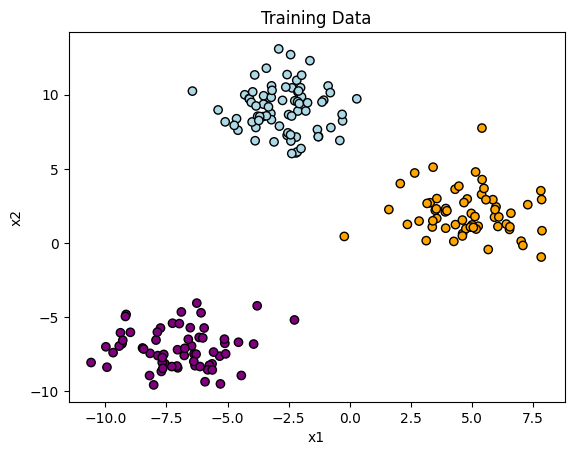

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin
from sklearn.preprocessing import PolynomialFeatures
from sklearn.datasets import make_blobs
from sklearn.utils.validation import check_is_fitted

from IPython.display import Markdown, display

def printmd(md_string):
    """
    Display a Markdown string in Jupyter.
    """
    display(Markdown(md_string))

# -------------------------------
# Custom Polynomial Transformer
# -------------------------------
class PolynomialFeaturesDegreeScaling(BaseEstimator, TransformerMixin):
    """
    Similar to sklearn's PolynomialFeatures but scales each
    column by (1 / scale_factor^degree_sum).
    """
    def __init__(self, degree=2, scale_factor=2.0, include_bias=True):
        self.degree = degree
        self.scale_factor = scale_factor
        self.include_bias = include_bias
        self.poly = PolynomialFeatures(degree=self.degree, include_bias=self.include_bias)
        self.powers_ = None

    def fit(self, X, y=None):
        self.poly.fit(X, y)
        # Store the powers array so we know the degree for each column
        self.powers_ = self.poly.powers_
        return self

    def transform(self, X):
        check_is_fitted(self, 'powers_')
        X_poly = self.poly.transform(X)
        
        # For each column, scale by (1 / scale_factor^(sum_of_exponents))
        for col_idx in range(X_poly.shape[1]):
            degree_sum = np.sum(self.powers_[col_idx])
            if degree_sum > 0:
                X_poly[:, col_idx] /= (self.scale_factor ** degree_sum)
        return X_poly

# -------------------------------
# Helper Functions
# -------------------------------
def one_hot(y, num_classes):
    return np.eye(num_classes)[y]

def softmax(logits):
    exp_shifted = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    return exp_shifted / np.sum(exp_shifted, axis=1, keepdims=True)

def compute_loss(probs, y, W, lam):
    N = len(y)
    nll = -np.mean(np.log(probs[np.arange(N), y] + 1e-32))
    reg = lam * np.sum(W * W)
    return nll + reg

def compute_gradient(X, probs, y, W, lam):
    N = X.shape[0]
    Y_one_hot = one_hot(y, W.shape[1])
    grad = (X.T @ (probs - Y_one_hot)) + 2 * lam * W
    return grad

def plot_decision_boundary(X, y, model, title, show_data=True):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    
    if model.W is None:
        model.initialize_weights(X)
    
    Z = model.predict(grid).reshape(xx.shape)
    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(colors))
    if show_data:
        plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", cmap=ListedColormap(colors))
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

# -------------------------------
# Multiclass Logistic Regression
# -------------------------------
class MulticlassLogReg(BaseEstimator, ClassifierMixin):
    def __init__(self, num_classes, lam=1e-2, lr=1e-4, max_iter=5000, degree=5, 
                 scale_factor=2.0, verbose=True, early_stopping=True, patience=10, tol=1e-3):
        """
        scale_factor: the factor used in PolynomialFeaturesDegreeScaling
        """
        self.num_classes = num_classes
        self.lam = lam
        self.lr = lr
        self.max_iter = max_iter
        self.degree = degree
        self.scale_factor = scale_factor
        self.verbose = verbose
        self.early_stopping = early_stopping
        self.patience = patience
        self.tol = tol
        self.W = None
        # Use our custom polynomial transformer
        self.poly = PolynomialFeaturesDegreeScaling(degree=self.degree,
                                                    scale_factor=self.scale_factor,
                                                    include_bias=True)
    
    def initialize_weights(self, X):
        # Fit polynomial on X (no scaling beyond the custom transform's approach)
        self.poly.fit(X)
        input_dim = self.poly.transform(X).shape[1]
        np.random.seed(0)
        self.W = 0.01 * np.random.randn(input_dim, self.num_classes)
    
    def fit(self, X, y, X_val=None, y_val=None, X_test=None, y_test=None):
        # Initialize polynomial and weights
        self.initialize_weights(X)
        X_poly = self.poly.transform(X)
        
        if X_val is not None:
            X_val_poly = self.poly.transform(X_val)
        else:
            X_val_poly = None
        
        if X_test is not None:
            X_test_poly = self.poly.transform(X_test)
        else:
            X_test_poly = None
        
        self.loss_history = []
        self.accuracy_history = []
        self.val_loss_history = []
        self.test_loss_history = []
        self.test_accuracy_history = []
        
        best_val_loss = float('inf')
        no_improve_count = 0
        
        for i in range(self.max_iter):
            # Training step
            logits = X_poly @ self.W
            probs = softmax(logits)
            loss = compute_loss(probs, y, self.W, self.lam)
            grad = compute_gradient(X_poly, probs, y, self.W, self.lam)
            self.W -= self.lr * grad
            
            self.loss_history.append(loss)
            accuracy = np.mean(np.argmax(probs, axis=1) == y)
            self.accuracy_history.append(accuracy)
            
            # Validation metrics
            if X_val_poly is not None:
                val_logits = X_val_poly @ self.W
                val_probs = softmax(val_logits)
                val_loss = compute_loss(val_probs, y_val, self.W, self.lam)
                self.val_loss_history.append(val_loss)
                
                if val_loss < best_val_loss - self.tol:
                    best_val_loss = val_loss
                    no_improve_count = 0
                else:
                    no_improve_count += 1
            
            # Test metrics
            if X_test_poly is not None:
                test_probs = softmax(X_test_poly @ self.W)
                test_loss = compute_loss(test_probs, y_test, self.W, self.lam)
                self.test_loss_history.append(test_loss)
                test_accuracy = np.mean(np.argmax(test_probs, axis=1) == y_test)
                self.test_accuracy_history.append(test_accuracy)
            
            # Verbose output every 100 iterations
            if self.verbose and i % 100 == 0:
                msg = f"Iter {i}: Train Loss={loss:.4f}, Train Acc={accuracy:.4f}"
                if X_val_poly is not None:
                    msg += f", Val Loss={val_loss:.4f}"
                if X_test_poly is not None:
                    msg += f", Test Loss={test_loss:.4f}, Test Acc={test_accuracy:.4f}"
                print(msg)
            
            if self.early_stopping and X_val_poly is not None and no_improve_count >= self.patience:
                print(f"Early stopping at iteration {i+1}")
                break
        
        return self
    
    def predict_proba(self, X):
        check_is_fitted(self, "W")
        X_poly = self.poly.transform(X)
        return softmax(X_poly @ self.W)
    
    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

# -------------------------------
# Data Generation and Splitting
# -------------------------------
palette = {"Light Blue": "#ADD8E6", "Orange": "#FFA500", "Purple": "#800080"}
colors = [palette["Light Blue"], palette["Orange"], palette["Purple"]]

np.random.seed(42)
X, y = make_blobs(n_samples=300, centers=3, cluster_std=1.5, random_state=42)

# Split the data into training, validation, and test sets
X_train, X_val, X_test = X[:200], X[200:250], X[250:]
y_train, y_val, y_test = y[:200], y[200:250], y[250:]

# Plot training data only
plt.figure()
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor="k", cmap=ListedColormap(colors))
plt.title("Training Data")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

# Training with a degree-based scaling

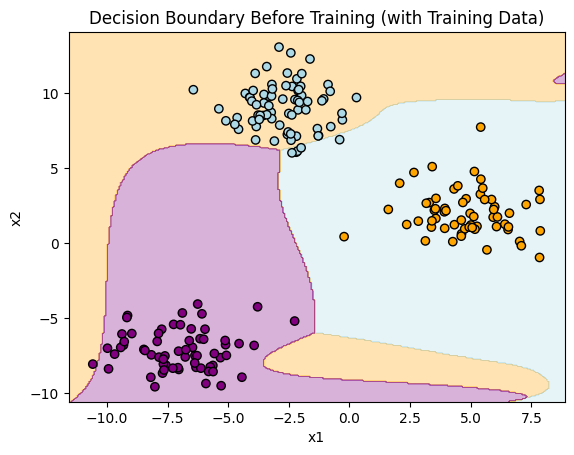

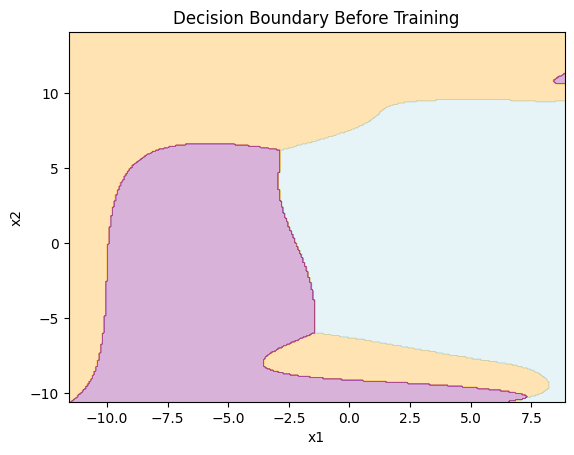


Training model with lambda = 1e-05
Iter 0: Train Loss=1.7276, Train Acc=0.3400, Val Loss=20.3385, Test Loss=15.8755, Test Acc=0.7000
Iter 100: Train Loss=15.3662, Train Acc=1.0000, Val Loss=19.6998, Test Loss=15.3648, Test Acc=1.0000
Iter 200: Train Loss=15.3594, Train Acc=1.0000, Val Loss=19.6559, Test Loss=15.3587, Test Acc=1.0000
Iter 300: Train Loss=15.3532, Train Acc=1.0000, Val Loss=19.6268, Test Loss=15.3527, Test Acc=1.0000
Iter 400: Train Loss=15.3470, Train Acc=1.0000, Val Loss=19.6039, Test Loss=15.3466, Test Acc=1.0000
Iter 500: Train Loss=15.3409, Train Acc=1.0000, Val Loss=19.5844, Test Loss=15.3405, Test Acc=1.0000
Iter 600: Train Loss=15.3348, Train Acc=1.0000, Val Loss=19.5671, Test Loss=15.3345, Test Acc=1.0000
Iter 700: Train Loss=15.3287, Train Acc=1.0000, Val Loss=19.5514, Test Loss=15.3284, Test Acc=1.0000
Iter 800: Train Loss=15.3226, Train Acc=1.0000, Val Loss=19.5369, Test Loss=15.3223, Test Acc=1.0000
Iter 900: Train Loss=15.3165, Train Acc=1.0000, Val Loss=1

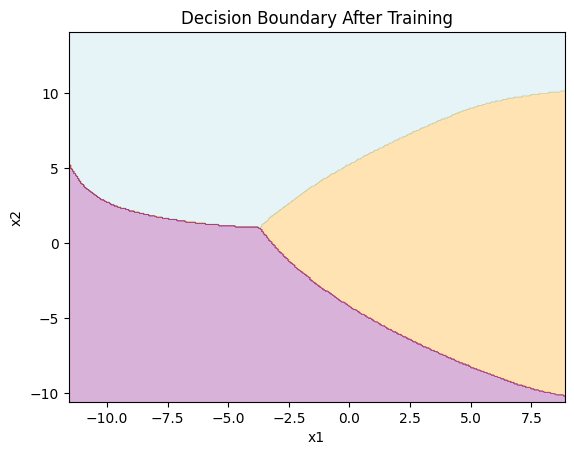

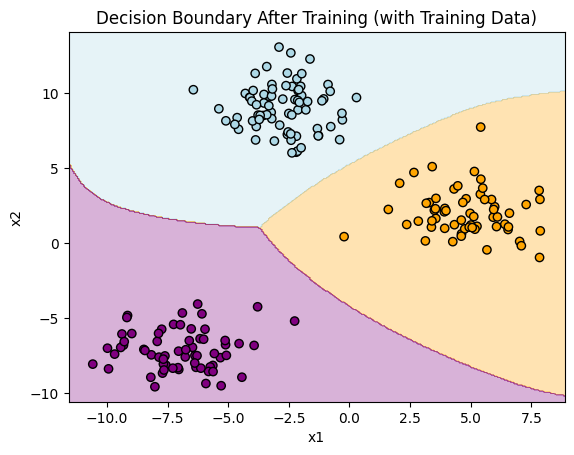

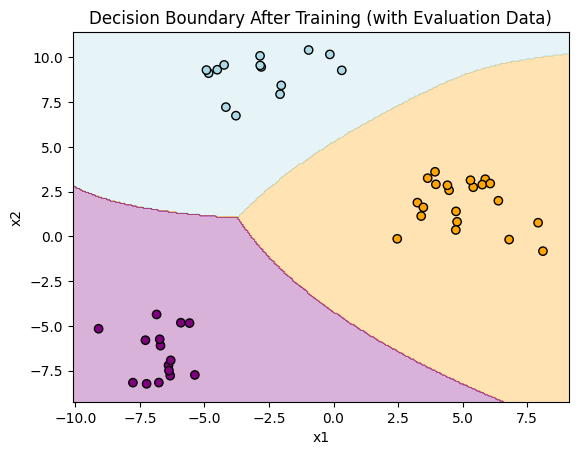

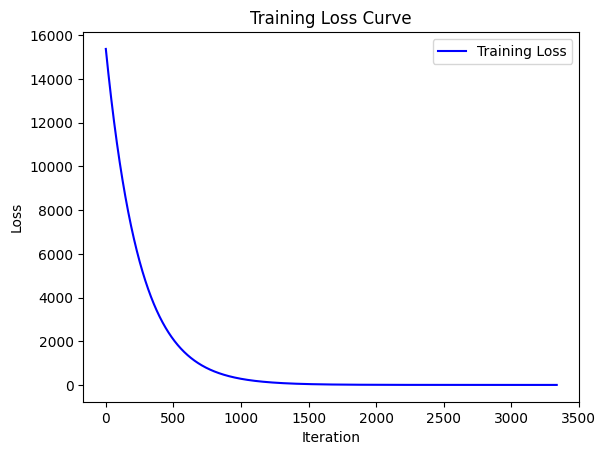

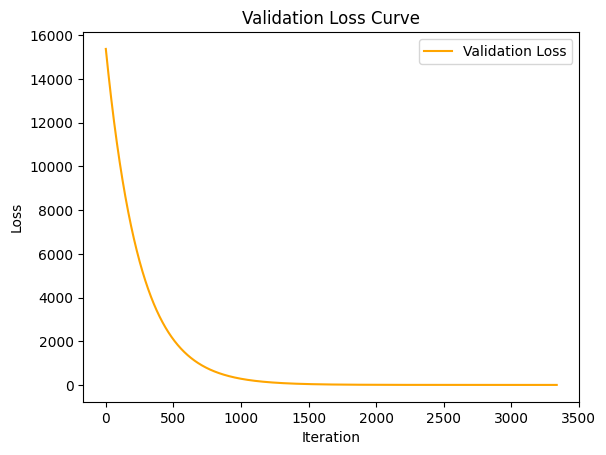

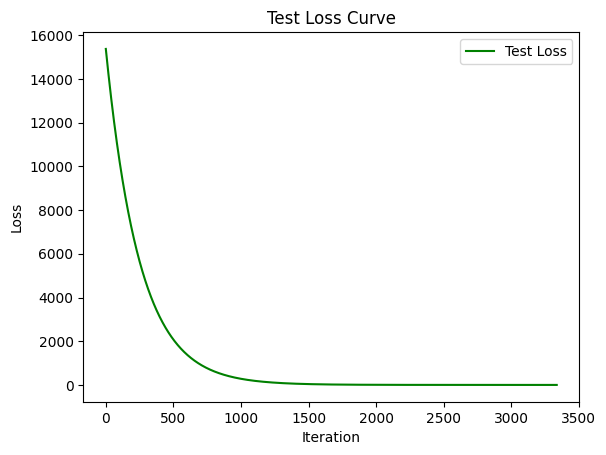

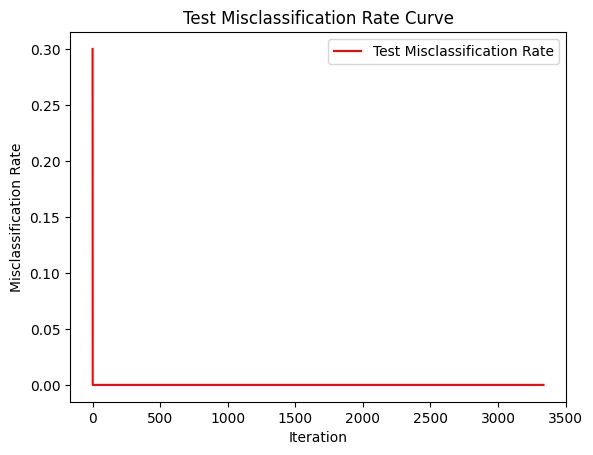

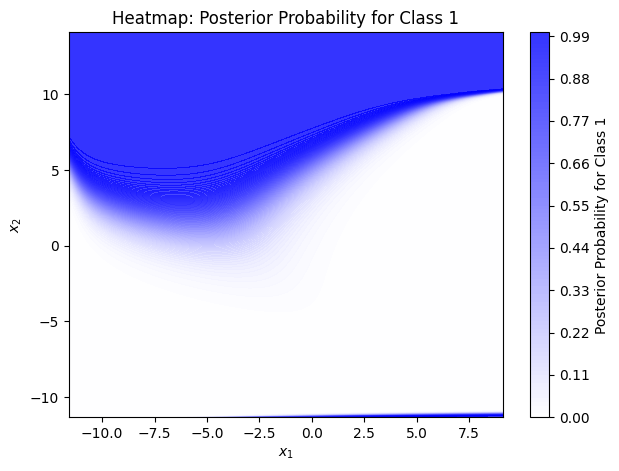

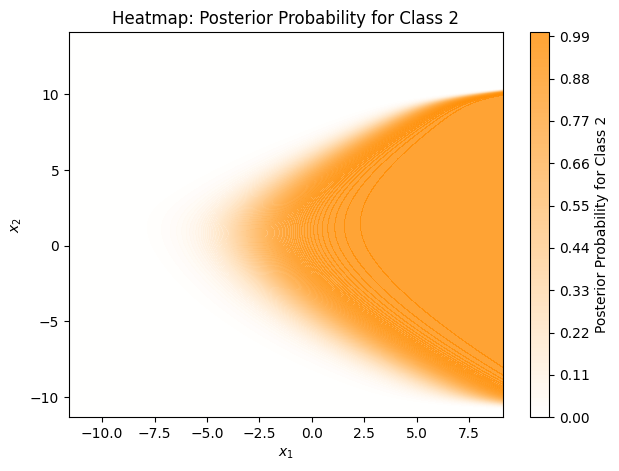

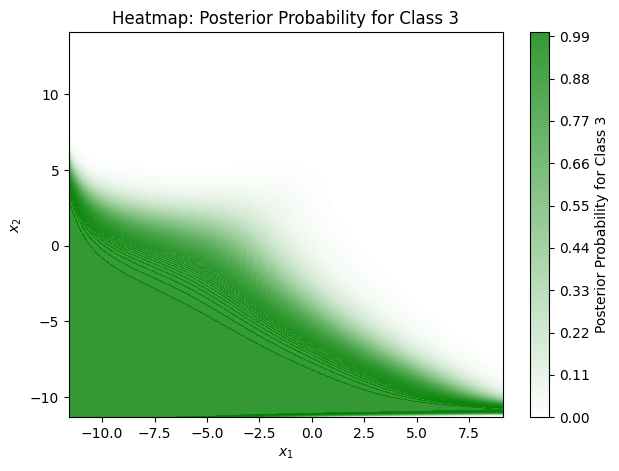

# Training without a degree-based scaling

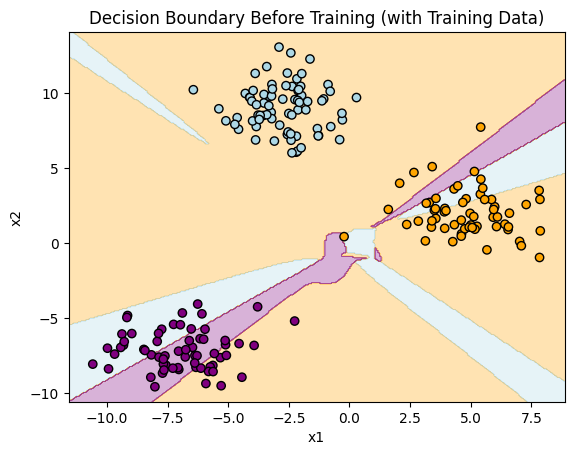

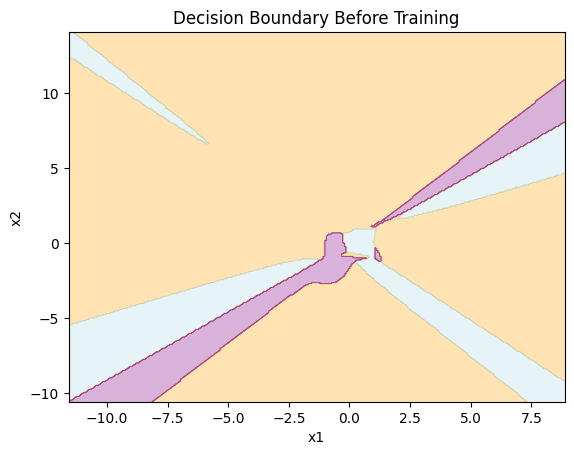


Training model with lambda = 1e-05
Iter 0: Train Loss=45.6888, Train Acc=0.3750, Val Loss=6166997796127851774672790576033538190760179665160029213818880.0000, Test Loss=6166997796127851774672790576033538190760179665160029213818880.0000, Test Acc=0.3800
Iter 100: Train Loss=6092990892213221283618234030648386575831411329515887429419008.0000, Train Acc=0.4850, Val Loss=6092272270510400677798039833992384242520381323431255832788992.0000, Test Loss=6092272270510400677798039833992384242520381323431255832788992.0000, Test Acc=0.4000
Iter 200: Train Loss=6023990938415530089464779741996779879444163276956162276196352.0000, Train Acc=0.4850, Val Loss=6023330133437741746393661546425335752277289812831912471822336.0000, Test Loss=6023330133437741746393661546425335752277289812831912471822336.0000, Test Acc=0.4000
Iter 300: Train Loss=5960769939528024179574274100377698042496907497983184507764736.0000, Train Acc=0.4900, Val Loss=5960166875475401258479822926520397163093573612494364686155776.0000, Test Lo

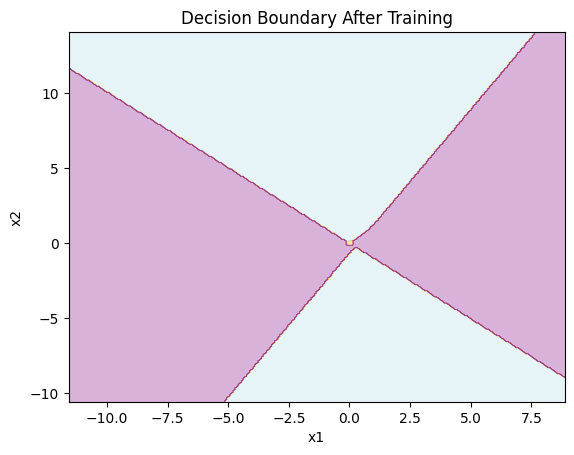

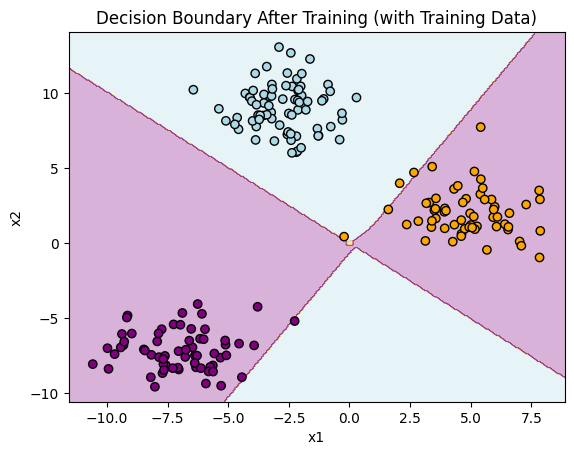

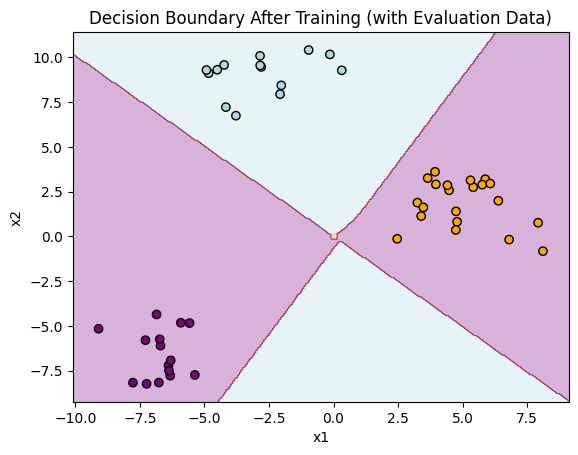

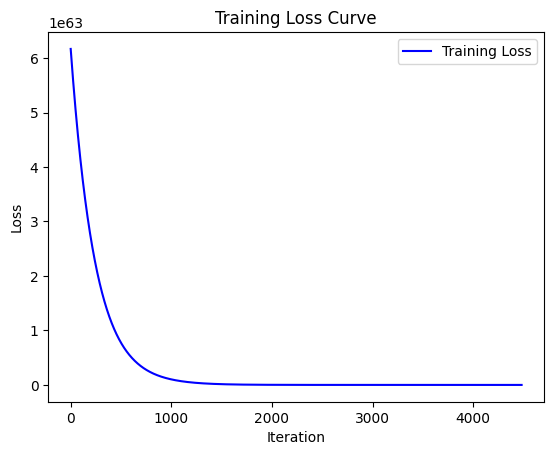

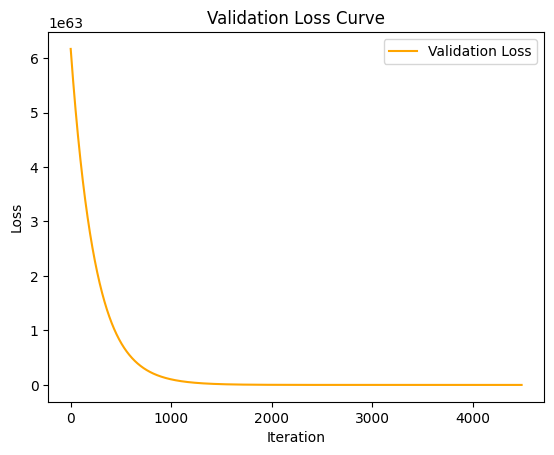

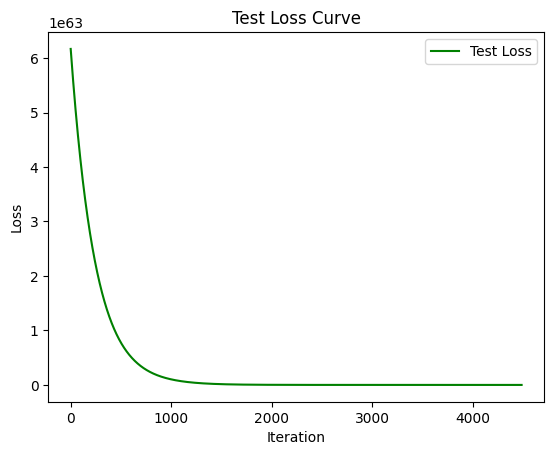

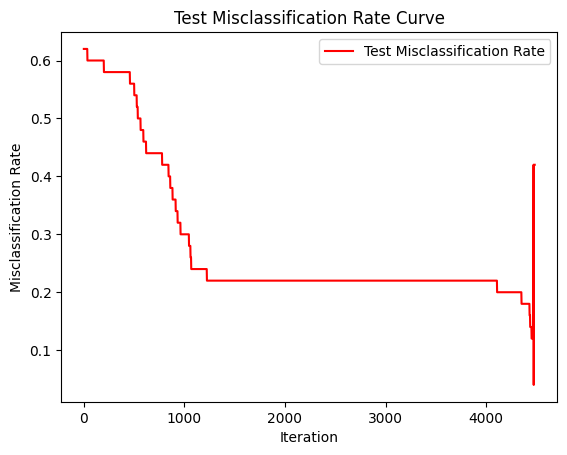

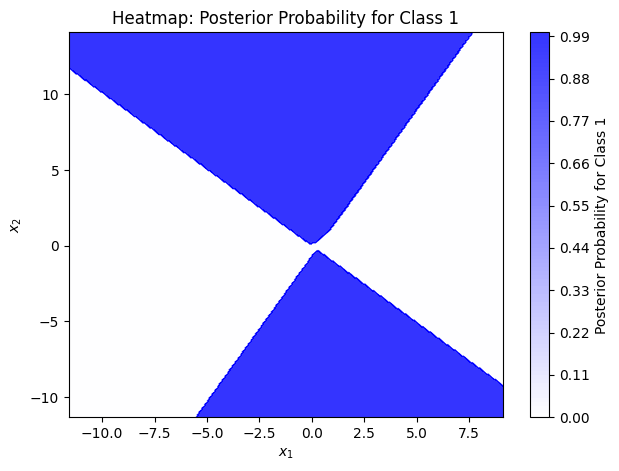

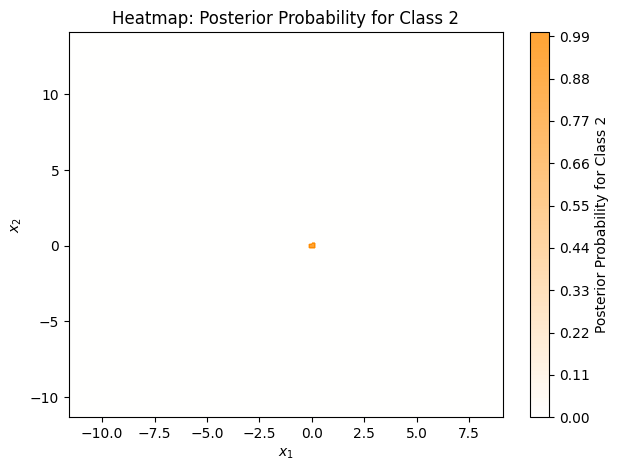

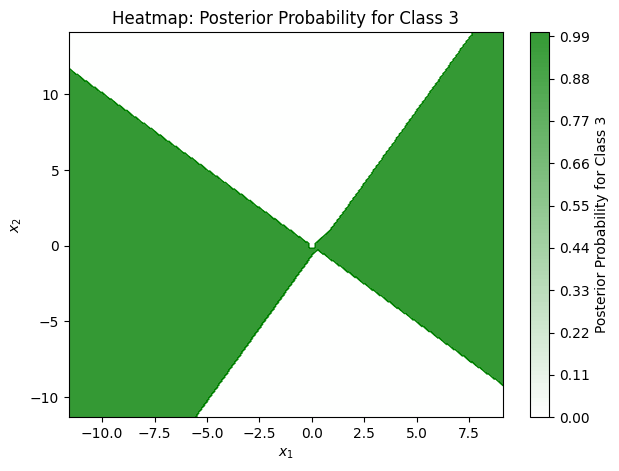

In [7]:
def experiment(degree_scale_factor=10.0):
    degree = 30
    # -- Draw Decision Boundary Before Training --
    # 1. Create an "untrained" model
    model_untrained = MulticlassLogReg(
        num_classes=3,
        degree=degree,
        scale_factor=degree_scale_factor,
        verbose=False
    )
    # 2. Initialize weights using the training set, 
    #    but do NOT call model_untrained.fit(...)
    model_untrained.initialize_weights(X_train)

    # 3. Plot the decision boundary with untrained weights
    plot_decision_boundary(
        X_train,
        y_train,
        model_untrained,
        "Decision Boundary Before Training (with Training Data)",
        show_data=True
    )
    plot_decision_boundary(X_train, y_train, model_untrained, "Decision Boundary Before Training", show_data=False)


    # -------------------------------
    # Hyperparameter Selection over Different Lambdas
    # -------------------------------
    lambdas = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1e0]
    best_lambda = None
    best_val_loss = float('inf')
    models = {}

    for lam in lambdas:
        print(f"\nTraining model with lambda = {lam}")
        model = MulticlassLogReg(num_classes=3, lam=lam, lr=1e-1, max_iter=10000, degree=degree,
                                scale_factor=degree_scale_factor, verbose=True, early_stopping=True, patience=10, tol=1e-3)
        model.fit(X_train, y_train, X_val, y_val, X_test, y_test)
        final_val_loss = model.val_loss_history[-1] if len(model.val_loss_history) > 0 else np.inf
        print(f"Final Validation Loss for lambda {lam}: {final_val_loss:.4f}")
        models[lam] = model
        if final_val_loss < best_val_loss:
            best_val_loss = final_val_loss
            best_lambda = lam

    print(f"\nBest lambda selected: {best_lambda} with validation loss: {best_val_loss:.4f}")
    best_model = models[best_lambda]

    # -------------------------------
    # Plot Decision Boundary
    # -------------------------------
    plot_decision_boundary(X_train, y_train, best_model, "Decision Boundary After Training", show_data=False)
    plot_decision_boundary(X_train, y_train, best_model, "Decision Boundary After Training (with Training Data)", show_data=True)
    plot_decision_boundary(X_test, y_test, best_model, "Decision Boundary After Training (with Evaluation Data)", show_data=True)

    # -------------------------------
    # Plot Loss and Accuracy Histories
    # -------------------------------
    # Training Loss Plot
    plt.figure()
    plt.plot(best_model.loss_history[1:], label="Training Loss", color="blue") # Skipping the iter-0 loss
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Training Loss Curve")
    plt.legend()
    plt.show()

    # Validation Loss Plot
    if best_model.val_loss_history:
        plt.figure()
        plt.plot(best_model.val_loss_history, label="Validation Loss", color="orange")
        plt.xlabel("Iteration")
        plt.ylabel("Loss")
        plt.title("Validation Loss Curve")
        plt.legend()
        plt.show()

    # Test Loss Plot
    if best_model.test_loss_history:
        plt.figure()
        plt.plot(best_model.test_loss_history, label="Test Loss", color="green")
        plt.xlabel("Iteration")
        plt.ylabel("Loss")
        plt.title("Test Loss Curve")
        plt.legend()
        plt.show()

    # Test Misclassification Rate Plot (1 - Test Accuracy)
    if best_model.test_accuracy_history:
        test_misclass_rate = [1 - acc for acc in best_model.test_accuracy_history]
        plt.figure()
        plt.plot(test_misclass_rate, label="Test Misclassification Rate", color="red")
        plt.xlabel("Iteration")
        plt.ylabel("Misclassification Rate")
        plt.title("Test Misclassification Rate Curve")
        plt.legend()
        plt.show()

    # -------------------------------
    # 学習後の各クラスの事後確率ヒートマップのプロット
    # -------------------------------
    # 全データの範囲に対してメッシュグリッドを作成
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    
    # グリッド上の全クラスに対する予測確率を取得 (shape: [num_points, 3])
    output_probs_all = best_model.predict_proba(grid)
    # ヒートマップ描画用にリシェイプ (shape: [300, 300, 3])
    output_probs_all = output_probs_all.reshape(xx.shape[0], xx.shape[1], 3)
    
    # 各クラスの色を定義（例：クラス0: 青，クラス1: ダークオレンジ，クラス2: 緑）
    class_color_map = {
        1: "#0000FF",  # Blue
        2: "#FF8C00",  # Dark Orange
        3: "#008000"   # Green
    }
    
    for class_idx, class_label in zip(range(3), [1, 2, 3]):
        # 対応クラスの色へのグラデーションカラーマップを作成 (低値は白，高値は指定色)
        cmap = LinearSegmentedColormap.from_list(f"heatmap_cmap_class{class_label}", ["white", class_color_map[class_label]])
    
        plt.figure(figsize=(7, 5))
        # 現在のクラスの確率マップを抽出
        prob_map = output_probs_all[:, :, class_idx]
        plt.contourf(xx, yy, prob_map, levels=100, cmap=cmap, alpha=0.8)
        plt.colorbar(label=f"Posterior Probability for Class {class_label}")
        plt.xlabel(r"$x_1$")
        plt.ylabel(r"$x_2$")
        plt.title(f"Heatmap: Posterior Probability for Class {class_label}")
        plt.show()


printmd("# Training with a degree-based scaling")
experiment(degree_scale_factor=10.0)

printmd("# Training without a degree-based scaling")
experiment(degree_scale_factor=1.0)

